# 01 — Data Retrieval (v2, Restart)

**EarningsLens · Columbia STAT GR5293**
Team: Timothy Chan · Yewen Li · Tiantian Hang

## Goals of this notebook
1. Build a **top-200 S&P 500 universe** (avg market cap 2010-2023) — keeps the project tractable.
2. Pull from WRDS only what we need: **CRSP daily/monthly, Compustat fundq, IBES, S&P 500 history, Capital IQ transcripts** for those 200 firms.
3. Save clean parquet files to **Google Drive** (`data/raw/`) so the team can share.
4. Run end-to-end sanity checks before NB02.

## Why a v2?
The original NB01 pulled 1.45M transcripts (~30GB) — too big for Colab and unnecessary for our research design. This version pulls **~11,200 transcripts (~3GB)** for the 200-firm subset.

## Estimated runtime
~30-45 minutes total (WRDS connection is the bottleneck).


## 0 · Colab Drive Setup

In [1]:
# Run this cell ONLY if you are on Google Colab.
# Skip it (or it will no-op) if running locally.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print("Not on Colab — using local paths.")
print(f"IN_COLAB = {IN_COLAB}")

Mounted at /content/drive
IN_COLAB = True


In [2]:
import os
from pathlib import Path

# ── Project root ──────────────────────────────────────────────────────────────
if IN_COLAB:
    PROJECT_ROOT = Path('/content/drive/MyDrive/EarningsLens')
else:
    # Set this to wherever your local project lives
    PROJECT_ROOT = Path.home() / 'EarningsLens'

RAW_DIR       = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"RAW_DIR       : {RAW_DIR}")
print(f"PROCESSED_DIR : {PROCESSED_DIR}")

PROJECT_ROOT  : /content/drive/MyDrive/EarningsLens
RAW_DIR       : /content/drive/MyDrive/EarningsLens/data/raw
PROCESSED_DIR : /content/drive/MyDrive/EarningsLens/data/processed


## 1 · Install & Import

In [3]:
# Run once per Colab session
%pip install -q wrds pandas pyarrow tqdm python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 83.5 MB/s eta 0:00:00


In [4]:
import warnings, sys
warnings.filterwarnings('ignore')

import wrds
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
from datetime import datetime

print(f"pandas {pd.__version__}  ·  numpy {np.__version__}  ·  wrds OK")

pandas 2.2.2  ·  numpy 2.0.2  ·  wrds OK


## 2 · Pipeline Configuration

Single source of truth. Change here, propagate everywhere.

In [5]:
# ── Pipeline window ───────────────────────────────────────────────────────────
START_DATE        = '2010-01-01'   # research window start
END_DATE          = '2023-12-31'   # research window end
RETURNS_END_DATE  = '2024-12-31'   # extend returns 1y past end for forward returns

# ── Universe filter ───────────────────────────────────────────────────────────
N_FIRMS           = 200            # top-N by avg market cap
RANKING_START     = '2010-01-01'   # window for computing avg market cap
RANKING_END       = '2023-12-31'

# ── CIQ transcript filter ─────────────────────────────────────────────────────
EARNINGS_CALL_KEYDEV_ID = 48       # KeyDev event type for earnings calls
COMPONENT_TYPE_IDS      = [2, 3, 4]  # Mgmt Pres, Analyst Q, Mgmt Answer

print(f"Window     : {START_DATE} → {END_DATE}  (returns until {RETURNS_END_DATE})")
print(f"Universe   : top {N_FIRMS} S&P 500 firms by avg mkt cap {RANKING_START}..{RANKING_END}")

Window     : 2010-01-01 → 2023-12-31  (returns until 2024-12-31)
Universe   : top 200 S&P 500 firms by avg mkt cap 2010-01-01..2023-12-31


## 3 · WRDS Connection

In [7]:
# WRDS will prompt for username/password the first time, then cache via .pgpass
# To avoid repeated prompts: set env vars or run wrds.Connection().create_pgpass_file() once
db = wrds.Connection()
print("WRDS connection OK — user:", db.list_libraries()[:1] and "✓")

Enter your WRDS username [root]:timothythchan1
Enter your password:··········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: y
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
WRDS connection OK — user: ✓


## 4 · Build Top-200 Universe

We use the **CRSP/Compustat link** + **CRSP monthly market cap** to rank S&P 500 ever-members by their average market cap during 2010-2023.

Output: `top200_universe.parquet` with columns `[permno, gvkey, ticker, comnam, avg_mcap]`.

In [8]:
# ── Step 4a · Pull CRSP monthly with market cap for screening ────────────────
print("Pulling CRSP monthly (this is the heaviest single query, ~2-3 min)...")
crsp_m_q = f'''
    SELECT a.permno, a.permco, a.date, a.ret, a.shrout, a.prc,
           ABS(a.prc) * a.shrout / 1000 AS mktcap_m,
           b.ticker, b.comnam, b.exchcd, b.shrcd
    FROM crsp.msf AS a
    LEFT JOIN crsp.msenames AS b
      ON a.permno = b.permno
     AND b.namedt <= a.date
     AND a.date  <= b.nameendt
    WHERE a.date BETWEEN '{START_DATE}' AND '{RETURNS_END_DATE}'
      AND b.exchcd IN (1, 2, 3)
      AND b.shrcd  IN (10, 11)
'''
crsp_m = db.raw_sql(crsp_m_q, date_cols=['date'])
print(f"  rows: {len(crsp_m):,}  ·  unique permnos: {crsp_m['permno'].nunique():,}")

Pulling CRSP monthly (this is the heaviest single query, ~2-3 min)...
  rows: 688,455  ·  unique permnos: 7,786


In [11]:
# ── Step 4b · Pull S&P 500 historical membership ─────────────────────────────
print("Pulling S&P 500 historical membership...")
sp500_q = '''
    SELECT gvkey, iid, gvkeyx, "from" AS sp_from, thru AS sp_thru
    FROM comp.idxcst_his
    WHERE gvkeyx = '000003'   -- S&P 500 index gvkeyx
'''
sp500_hist = db.raw_sql(sp500_q, date_cols=['sp_from', 'sp_thru'])
print(f"  S&P 500 ever-members: {sp500_hist['gvkey'].nunique():,}")

Pulling S&P 500 historical membership...
  S&P 500 ever-members: 500


In [12]:
# ── Step 4c · CRSP/Compustat link (gvkey ↔ permno) ───────────────────────────
print("Pulling CRSP/Compustat link table...")
link_q = '''
    SELECT gvkey, lpermno AS permno, lpermco AS permco, linktype, linkprim,
           linkdt, linkenddt
    FROM crsp.ccmxpf_linktable
    WHERE linktype IN ('LU', 'LC')
      AND linkprim IN ('P', 'C')
'''
link = db.raw_sql(link_q, date_cols=['linkdt', 'linkenddt'])
link['linkenddt'] = link['linkenddt'].fillna(pd.Timestamp('2099-12-31'))
print(f"  link rows: {len(link):,}")

Pulling CRSP/Compustat link table...
  link rows: 33,324


In [13]:
# ── Step 4d · Filter S&P 500 firms that were members in our window ────────────
sp_in_window = sp500_hist[
    (sp500_hist['sp_from'] <= pd.Timestamp(RANKING_END)) &
    ((sp500_hist['sp_thru'].isna()) | (sp500_hist['sp_thru'] >= pd.Timestamp(RANKING_START)))
].copy()
print(f"S&P 500 members during {RANKING_START}..{RANKING_END}: {sp_in_window['gvkey'].nunique():,}")

# Map to permno
sp_with_permno = (sp_in_window.merge(link[['gvkey', 'permno', 'linkdt', 'linkenddt']], on='gvkey')
    .query('linkdt <= @RANKING_END and linkenddt >= @RANKING_START')
    [['gvkey', 'permno']].drop_duplicates())
print(f"S&P 500 unique permnos with link: {sp_with_permno['permno'].nunique():,}")

S&P 500 members during 2010-01-01..2023-12-31: 460
S&P 500 unique permnos with link: 470


In [14]:
# ── Step 4e · Compute avg market cap and rank top-200 ─────────────────────────
mcap = (crsp_m
    .query('@RANKING_START <= date <= @RANKING_END')
    .merge(sp_with_permno, on='permno', how='inner')
    .groupby('permno')
    .agg(avg_mcap=('mktcap_m', 'mean'),
         n_months=('mktcap_m', 'size'),
         ticker=('ticker', 'last'),
         comnam=('comnam', 'last'))
    .reset_index())

# Require ≥36 months in window (3y minimum) to ensure stable ranking
mcap_stable = mcap.query('n_months >= 36').sort_values('avg_mcap', ascending=False)

top200 = mcap_stable.head(N_FIRMS).copy()
top200 = top200.merge(sp_with_permno, on='permno', how='left')
top200_permnos = top200['permno'].astype(int).tolist()
top200_gvkeys = top200['gvkey'].astype(str).str.zfill(6).unique().tolist()

print(f"\n✓ Top-{N_FIRMS} universe built")
print(f"  Mean avg mcap (top 5)  : ${top200.head(5)['avg_mcap'].mean()/1000:,.1f} B")
print(f"  Median avg mcap (top200): ${top200['avg_mcap'].median()/1000:,.1f} B")
print(f"\nTop 10 by avg market cap:")
print(top200.head(10)[['ticker', 'comnam', 'avg_mcap']].to_string(index=False))

top200.to_parquet(RAW_DIR / 'top200_universe.parquet', index=False)
print(f"\n💾 Saved → {RAW_DIR / 'top200_universe.parquet'}")


✓ Top-200 universe built
  Mean avg mcap (top 5)  : $665.2 B
  Median avg mcap (top200): $47.8 B

Top 10 by avg market cap:
ticker              comnam        avg_mcap
  AAPL           APPLE INC  1090570.476444
  MSFT      MICROSOFT CORP   889444.612038
  AMZN      AMAZON COM INC   631909.794635
  META  META PLATFORMS INC   365152.308905
   XOM    EXXON MOBIL CORP   348854.392112
 GOOGL        ALPHABET INC   347058.847738
   JNJ   JOHNSON & JOHNSON   312968.564181
   JPM JPMORGAN CHASE & CO   287033.999347
   WMT         WALMART INC   281286.131616
    PG PROCTER & GAMBLE CO   248691.773537

💾 Saved → /content/drive/MyDrive/EarningsLens/data/raw/top200_universe.parquet


## 5 · Pull CRSP Daily Returns for Top-200

In [15]:
# CRSP daily — only for our 200 permnos, much smaller pull
permno_list = ','.join(str(p) for p in top200_permnos)

print(f"Pulling CRSP daily for {len(top200_permnos)} permnos ({START_DATE} → {RETURNS_END_DATE})...")
crsp_d_q = f'''
    SELECT permno, date, ret, retx, prc, vol, shrout,
           ABS(prc) * shrout / 1000 AS mktcap_d
    FROM crsp.dsf
    WHERE permno IN ({permno_list})
      AND date BETWEEN '{START_DATE}' AND '{RETURNS_END_DATE}'
'''
crsp_d = db.raw_sql(crsp_d_q, date_cols=['date'])
print(f"  rows: {len(crsp_d):,}  (~{len(crsp_d)/len(top200_permnos):,.0f} daily obs per firm)")
crsp_d.to_parquet(RAW_DIR / 'crsp_daily.parquet', index=False)
print(f"💾 Saved → {RAW_DIR / 'crsp_daily.parquet'}  ({(RAW_DIR/'crsp_daily.parquet').stat().st_size/1e6:.1f} MB)")

Pulling CRSP daily for 200 permnos (2010-01-01 → 2024-12-31)...
  rows: 716,322  (~3,582 daily obs per firm)
💾 Saved → /content/drive/MyDrive/EarningsLens/data/raw/crsp_daily.parquet  (17.0 MB)


In [16]:
# CRSP monthly subset (for our 200 firms only)
crsp_m_top200 = crsp_m[crsp_m['permno'].isin(top200_permnos)].copy()
crsp_m_top200.to_parquet(RAW_DIR / 'crsp_monthly.parquet', index=False)
print(f"CRSP monthly (top-200): {len(crsp_m_top200):,} rows  →  {(RAW_DIR/'crsp_monthly.parquet').stat().st_size/1e6:.1f} MB")

CRSP monthly (top-200): 33,837 rows  →  1.0 MB


## 6 · Pull Compustat Fundamentals (Quarterly)

In [17]:
gvkey_quoted = ','.join(f"'{g}'" for g in top200_gvkeys)

print(f"Pulling Compustat fundq for {len(top200_gvkeys)} gvkeys...")
fundq_q = f'''
    SELECT gvkey, datadate, fyearq, fqtr, rdq, conm,
           saleq, revtq, cogsq, oibdpq, niq, epspxq, epsfxq,
           atq, ltq, cheq, dlcq, dlttq, ceqq, seqq,
           cshoq, prccq
    FROM comp.fundq
    WHERE gvkey IN ({gvkey_quoted})
      AND indfmt = 'INDL' AND datafmt = 'STD' AND popsrc = 'D' AND consol = 'C'
      AND datadate BETWEEN '{START_DATE}' AND '{END_DATE}'
'''
fundq = db.raw_sql(fundq_q, date_cols=['datadate', 'rdq'])
print(f"  rows: {len(fundq):,}  ·  unique gvkeys: {fundq['gvkey'].nunique():,}")
fundq.to_parquet(RAW_DIR / 'compustat_fundq.parquet', index=False)
print(f"💾 Saved → {RAW_DIR / 'compustat_fundq.parquet'}")

Pulling Compustat fundq for 198 gvkeys...
  rows: 10,850  ·  unique gvkeys: 198
💾 Saved → /content/drive/MyDrive/EarningsLens/data/raw/compustat_fundq.parquet


## 7 · Pull IBES Analyst Forecasts (Optional, for benchmarking)

In [18]:
# IBES uses CUSIP — get CRSP-IBES link via permno → ncusip
# We pull statsum for ticker-level forecasts; map back to permno later.
print("Pulling IBES quarterly summary (one-quarter-ahead EPS)...")
ibes_q = f'''
    SELECT i.ticker, i.cusip, i.statpers, i.fpedats, i.fpi,
           i.numest, i.medest, i.meanest, i.stdev, i.actual
    FROM ibes.statsum_epsus AS i
    WHERE i.fpi = '6'
      AND i.statpers BETWEEN '{START_DATE}' AND '{END_DATE}'
'''
ibes = db.raw_sql(ibes_q, date_cols=['statpers', 'fpedats'])
print(f"  rows: {len(ibes):,}  ·  unique IBES tickers: {ibes['ticker'].nunique():,}")
ibes.to_parquet(RAW_DIR / 'ibes_statsum.parquet', index=False)
print(f"💾 Saved → {RAW_DIR / 'ibes_statsum.parquet'}")

Pulling IBES quarterly summary (one-quarter-ahead EPS)...
  rows: 701,752  ·  unique IBES tickers: 9,140
💾 Saved → /content/drive/MyDrive/EarningsLens/data/raw/ibes_statsum.parquet


## 8 · Pull Fama-French Factors

In [19]:
print("Pulling Fama-French 5-factor monthly...")
ff_q = f'''
    SELECT date, mktrf, smb, hml, rmw, cma, rf, umd
    FROM ff.fivefactors_monthly AS f
    LEFT JOIN ff.factors_monthly AS m USING (date)
    WHERE date BETWEEN '{START_DATE}' AND '{RETURNS_END_DATE}'
'''
try:
    ff = db.raw_sql(ff_q, date_cols=['date'])
except Exception:
    # fallback if join fails
    ff = db.raw_sql(f"SELECT * FROM ff.fivefactors_monthly WHERE date BETWEEN '{START_DATE}' AND '{RETURNS_END_DATE}'",
                    date_cols=['date'])
print(f"  rows: {len(ff):,}")
ff.to_parquet(RAW_DIR / 'ff_factors_monthly.parquet', index=False)
print(f"💾 Saved → {RAW_DIR / 'ff_factors_monthly.parquet'}")

Pulling Fama-French 5-factor monthly...
  rows: 180
💾 Saved → /content/drive/MyDrive/EarningsLens/data/raw/ff_factors_monthly.parquet


## 9 · Capital IQ Transcripts — Top-200 Only

This is the big one. We map our 200 firms to **CIQ companyids** (via ticker), then pull only their **earnings call transcripts** within our window.

Expected: ~200 firms × 56 quarters = **~11,200 transcripts**.

In [30]:
print("Inspecting columns in ciq_transcripts.wrds_transcript_detail...")
columns = db.describe_table('ciq_transcripts', 'wrds_transcript_detail')
display(columns)

Inspecting columns in ciq_transcripts.wrds_transcript_detail...
Approximately 1771010 rows in ciq_transcripts.wrds_transcript_detail.


,name,nullable,type,comment
0,companyid,True,"NUMERIC(11, 0)",Company ID
1,keydevid,True,"NUMERIC(11, 0)",Key Dev ID
2,transcriptid,True,"NUMERIC(11, 0)",Transcript ID
3,headline,True,VARCHAR(381),Event Headline
4,mostimportantdateutc,True,DATE,Most Important Date UTC
5,mostimportanttimeutc,True,TIME,Most Important Time UTC
6,keydeveventtypeid,True,"NUMERIC(11, 0)",Key Development/Event Type ID
7,keydeveventtypename,True,VARCHAR(52),Key Development/Event Type Name
8,companyname,True,VARCHAR(115),Company Name
9,transcriptcollectiontypeid,True,INTEGER,Transcript Collection Type ID


In [25]:
# ── Step 9a · Get CIQ companyid for each gvkey via ciq.wrds_gvkey ───
gvkey_quoted = ','.join(f"'{str(g).zfill(6)}'" for g in top200['gvkey'].dropna().unique())

print("Mapping gvkeys → CIQ companyids...")
ciq_map_q = f'''
    SELECT DISTINCT companyid, gvkey
    FROM ciq.wrds_gvkey
    WHERE gvkey IN ({gvkey_quoted})
'''
ciq_map = db.raw_sql(ciq_map_q)
ciq_map.columns = [c.lower() for c in ciq_map.columns]

# Bring the ticker back into our mapping table so downstream code still works
ciq_map = ciq_map.merge(top200[['gvkey', 'ticker']], on='gvkey', how='left')

print(f"  CIQ companies matched: {ciq_map['companyid'].nunique():,} / {len(top200)} target firms")

ciq_map.to_parquet(RAW_DIR / 'ciq_company_map.parquet', index=False)

Mapping gvkeys → CIQ companyids...
  CIQ companies matched: 208 / 200 target firms


In [26]:
# ── Step 9b · Pull transcript metadata (filter early!) ───────────────────────
companyid_list = ','.join(str(int(c)) for c in ciq_map['companyid'].unique())

print(f"Pulling earnings-call transcript metadata for {ciq_map['companyid'].nunique()} CIQ firms...")
meta_q = f'''
    SELECT d.companyid, d.companyname,
           d.transcriptid, d.keydeveventtypeid, d.keydevid,
           d.mostimportantdateutc AS event_date,
           d.transcriptcreationdate_utc AS created_date
    FROM ciq_transcripts.wrds_transcript_detail AS d
    WHERE d.companyid IN ({companyid_list})
      AND d.keydeveventtypeid = {EARNINGS_CALL_KEYDEV_ID}
      AND d.mostimportantdateutc BETWEEN '{START_DATE}' AND '{END_DATE}'
'''
meta = db.raw_sql(meta_q, date_cols=['event_date', 'created_date'])

# Merge ticker from mapping
meta = meta.merge(ciq_map[['companyid', 'ticker']], on='companyid', how='left')

# De-dup: keep the latest transcript per (companyid, event_date)
meta = (meta.sort_values('created_date')
            .drop_duplicates(['companyid', 'event_date'], keep='last')
            .reset_index(drop=True))

print(f"  earnings-call transcripts: {len(meta):,}")
print(f"  per-firm avg : {len(meta)/meta['companyid'].nunique():.1f}")
meta.to_parquet(RAW_DIR / 'ciq_transcript_meta.parquet', index=False)
print(f"💾 Saved → {RAW_DIR / 'ciq_transcript_meta.parquet'}")

Pulling earnings-call transcript metadata for 208 CIQ firms...
  earnings-call transcripts: 10,451
  per-firm avg : 53.1
💾 Saved → /content/drive/MyDrive/EarningsLens/data/raw/ciq_transcript_meta.parquet


In [27]:
# ── Step 9c · Pull transcript components in BATCHES (memory-friendly) ────────
# componenttext can be very long; we process 500 transcripts at a time.

transcript_ids = meta['transcriptid'].astype(int).tolist()
print(f"Pulling components for {len(transcript_ids):,} transcripts in batches of 500...")

BATCH = 500
all_chunks = []

for i in tqdm(range(0, len(transcript_ids), BATCH)):
    batch_ids = transcript_ids[i:i+BATCH]
    id_list = ','.join(str(x) for x in batch_ids)
    comp_q = f'''
        SELECT c.transcriptid, c.transcriptcomponentid, c.componentorder,
               c.transcriptcomponenttypeid AS component_type_id,
               c.componenttext
        FROM ciq_transcripts.ciqtranscriptcomponent AS c
        WHERE c.transcriptid IN ({id_list})
          AND c.transcriptcomponenttypeid IN ({','.join(str(t) for t in COMPONENT_TYPE_IDS)})
    '''
    chunk = db.raw_sql(comp_q)
    all_chunks.append(chunk)

components = pd.concat(all_chunks, ignore_index=True)
print(f"\n  components: {len(components):,}  ·  avg {len(components)/len(transcript_ids):.1f}/transcript")

Pulling components for 10,451 transcripts in batches of 500...


  0%|          | 0/21 [00:00<?, ?it/s]


  components: 624,243  ·  avg 59.7/transcript


In [28]:
# ── Step 9d · Join meta + components, save final transcripts.parquet ─────────
transcripts = components.merge(meta, on='transcriptid', how='left')

# Component label mapping
COMPONENT_LABELS = {2: 'Mgmt Presentation', 3: 'Analyst Question', 4: 'Mgmt Answer'}
transcripts['component_label'] = transcripts['component_type_id'].map(COMPONENT_LABELS)

# Quarter / fiscal-year columns derived from event_date
transcripts['quarter'] = pd.to_datetime(transcripts['event_date']).dt.to_period('Q').astype(str)
transcripts['year']    = pd.to_datetime(transcripts['event_date']).dt.year

# Reorder columns for clarity
final_cols = ['transcriptid', 'companyid', 'companyname', 'ticker',
              'event_date', 'year', 'quarter',
              'component_type_id', 'component_label',
              'componentorder', 'componenttext',
              'keydeveventtypeid', 'keydevid', 'created_date',
              'transcriptcomponentid']
transcripts = transcripts[final_cols]

# Sort and save
transcripts = transcripts.sort_values(['companyid', 'event_date', 'componentorder']).reset_index(drop=True)
transcripts.to_parquet(RAW_DIR / 'ciq_transcripts.parquet', index=False)
size_mb = (RAW_DIR / 'ciq_transcripts.parquet').stat().st_size / 1e6
print(f"💾 Saved → {RAW_DIR / 'ciq_transcripts.parquet'}  ({size_mb:.1f} MB)")
print(f"   {len(transcripts):,} components  ·  {transcripts['transcriptid'].nunique():,} transcripts  ·  {transcripts['ticker'].nunique()} tickers")

💾 Saved → /content/drive/MyDrive/EarningsLens/data/raw/ciq_transcripts.parquet  (295.0 MB)
   624,243 components  ·  10,443 transcripts  ·  197 tickers


## 10 · Sanity Checks

In [29]:
print("=" * 60)
print("DATA RETRIEVAL SUMMARY")
print("=" * 60)

files = [
    ('top200_universe.parquet',     'Top-200 firm universe'),
    ('crsp_daily.parquet',          'CRSP daily returns'),
    ('crsp_monthly.parquet',        'CRSP monthly returns'),
    ('compustat_fundq.parquet',     'Compustat fundamentals (quarterly)'),
    ('ibes_statsum.parquet',        'IBES analyst forecasts'),
    ('ff_factors_monthly.parquet',  'Fama-French factors'),
    ('ciq_company_map.parquet',     'CIQ ticker → companyid map'),
    ('ciq_transcript_meta.parquet', 'Transcript metadata'),
    ('ciq_transcripts.parquet',     'Transcript components (full text)'),
]
total_mb = 0
for fname, desc in files:
    fp = RAW_DIR / fname
    if fp.exists():
        size_mb = fp.stat().st_size / 1e6
        total_mb += size_mb
        rows = len(pd.read_parquet(fp, columns=[pd.read_parquet(fp, columns=None).columns[0]]) if size_mb < 100 else pd.DataFrame())
        print(f"  ✓ {fname:35s} {size_mb:8.1f} MB  · {desc}")
    else:
        print(f"  ✗ {fname:35s}      MISSING  · {desc}")
print(f"\nTotal raw data : {total_mb:,.1f} MB")

DATA RETRIEVAL SUMMARY
  ✓ top200_universe.parquet                  0.0 MB  · Top-200 firm universe
  ✓ crsp_daily.parquet                      17.0 MB  · CRSP daily returns
  ✓ crsp_monthly.parquet                     1.0 MB  · CRSP monthly returns
  ✓ compustat_fundq.parquet                  1.0 MB  · Compustat fundamentals (quarterly)
  ✓ ibes_statsum.parquet                     4.6 MB  · IBES analyst forecasts
  ✓ ff_factors_monthly.parquet               0.0 MB  · Fama-French factors
  ✓ ciq_company_map.parquet                  0.0 MB  · CIQ ticker → companyid map
  ✓ ciq_transcript_meta.parquet              0.2 MB  · Transcript metadata
  ✓ ciq_transcripts.parquet                295.0 MB  · Transcript components (full text)

Total raw data : 318.7 MB


In [31]:
# Coverage assertions — fail loudly if pulls were incomplete
top200_df = pd.read_parquet(RAW_DIR / 'top200_universe.parquet')
crsp_d_df = pd.read_parquet(RAW_DIR / 'crsp_daily.parquet', columns=['permno', 'date'])
trans_df  = pd.read_parquet(RAW_DIR / 'ciq_transcripts.parquet', columns=['ticker', 'transcriptid', 'event_date'])

assert len(top200_df) == N_FIRMS, f"Universe size {len(top200_df)} ≠ {N_FIRMS}"
assert crsp_d_df['permno'].nunique() >= int(N_FIRMS * 0.95), "CRSP coverage <95% of universe"
unique_transcripts = trans_df['transcriptid'].nunique()
assert unique_transcripts >= 5000, f"Only {unique_transcripts} transcripts — too few, expected ~11,000"

# Per-firm transcript count distribution
per_firm = trans_df.groupby('ticker')['transcriptid'].nunique().describe()
print("Transcripts per firm (distribution):")
print(per_firm.to_string())
print(f"\n✓ All sanity checks passed. {unique_transcripts:,} unique transcripts across {trans_df['ticker'].nunique()} tickers.")

Transcripts per firm (distribution):
count    197.000000
mean      53.010152
std        8.676728
min        2.000000
25%       55.000000
50%       56.000000
75%       56.000000
max       62.000000

✓ All sanity checks passed. 10,443 unique transcripts across 197 tickers.


## 11 · Quick EDA

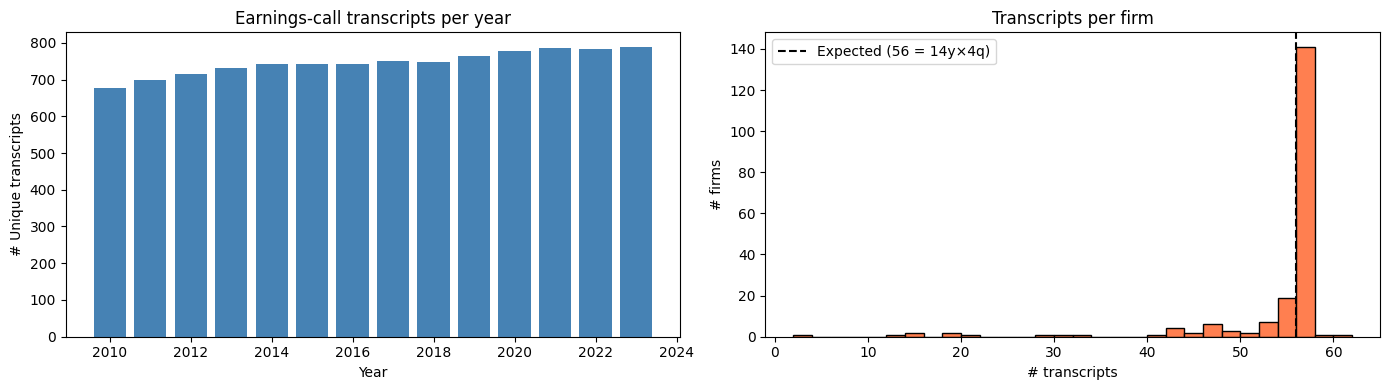

In [32]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Transcripts per year
trans_df['year'] = pd.to_datetime(trans_df['event_date']).dt.year
yearly = trans_df.groupby('year')['transcriptid'].nunique()
axes[0].bar(yearly.index, yearly.values, color='steelblue')
axes[0].set_title('Earnings-call transcripts per year')
axes[0].set_xlabel('Year'); axes[0].set_ylabel('# Unique transcripts')

# Distribution of transcripts per firm
per_firm_count = trans_df.groupby('ticker')['transcriptid'].nunique()
axes[1].hist(per_firm_count, bins=30, color='coral', edgecolor='black')
axes[1].axvline(56, color='black', linestyle='--', label='Expected (56 = 14y×4q)')
axes[1].set_title('Transcripts per firm')
axes[1].set_xlabel('# transcripts'); axes[1].set_ylabel('# firms'); axes[1].legend()

plt.tight_layout(); plt.show()

## 12 · Done — Hand-off to NB02

**Outputs saved to** `data/raw/` on Google Drive:
- Universe & link tables
- CRSP daily/monthly · Compustat · IBES · FF factors
- ~11,000 earnings-call transcripts for the top-200 firms

**Next:** open `02_spacy_baseline_v2.ipynb` to extract candidate forward-looking targets with a stronger spaCy pipeline (`en_core_web_trf` + improved `normalize_target`).


In [33]:
db.close()
print("WRDS connection closed. NB01 complete.")

WRDS connection closed. NB01 complete.
